# Starfinder: Soldier with Magnetar Rifle

Advanced weapons are available to all martial characters through the {srd_feats}`Weapon Proficiency <911-weapon-proficiency>` general feat.
However, with Weapon Proficiency, when you hit level 5 your proficiency with martial weapons increases to expert, but not that with advanced weapons. This is unlike ancestral Weapon Familiarity feats.

The {srd_weapons}`Magnetar Rifle <68-magnetar-rifle>` is an advanced weapon (d12 Analog, Automatic, range 60ft, magazine 30).
The closest match with martial weapons is the substantially worse {srd_weapons}`Rotolaser <58-rotolaser>` (d8 Automatic, Tech, range 30ft, magazine 10).

Crucially, Area Fire and Auto-Fire use one's class proficiency, not the weapon proficiency - which raises the question of how do the damage profiles for the two weapons compare.
So a {srd_classes}`Soldier<5-soldier>` using a Magnetar Rifle would use their lowered weapon proficiency for Primary Target and simple Strikes, and their full class proficiency for Auto-fire.

Let's analyse a full round of firing a rotolaser and compare it with a magnetar rifle.
With both weapons, we'll do Primary target -> Auto-Fire against a single target -> simple Strike.

In [1]:
import xarray

import pathfinder2e_stats as pf2

%matplotlib inline

In [2]:
level = 5

atk = xarray.DataArray(
    [14, 12, 12, 12],  # level 5 + trained 2 or expert 4 + dex 4 + tracking 1
    dims=["weapon"],
    coords={"weapon": [
        "Zero Cannon (Punishing Salvo)",
        "Magnetar Rifle (auto-fire)",
        "Magnetar Rifle (3 shots)",
        "Magnetar Rifle (Overwhelming Assault)",
    ]},
)

area_fire_DC = 22  # 10 + level 5 + trained 2 + con 4 + tracking 1

zero_cannon = pf2.Damage("cold", 2, 10)
magnetar_rifle = pf2.Damage("piercing", 2, 12)

enemy = pf2.tables.SIMPLE_NPC.sel(level=level, drop=True)[["AC", "saving_throws", "HP"]]
enemy.to_pandas()

,AC,saving_throws,HP
challenge,,,
Weak,16,6,31
Matched,21,12,75
Boss,25,18,148


In [3]:
# both 'weapon' and 'challenge' are what-if analyses - let's compare the same dice rolls
# against progressively harder-to-hit enemies.
pf2.set_config(
    check_dependent_dims=("challenge", "weapon"),
    damage_dependent_dims=("challenge", "weapon"),
)

In [4]:
primary_target = pf2.check(atk, DC=enemy.AC)
primary_target = xarray.concat(
    [
        pf2.damage(primary_target.isel(weapon=slice(1)), zero_cannon),
        pf2.damage(primary_target.isel(weapon=slice(1, None)), magnetar_rifle),
    ],
    data_vars="all",
    dim="weapon",
    join="outer",
    fill_value=0,
)

In [5]:
auto_fire = pf2.check(
    enemy.saving_throws, DC=area_fire_DC, primary_target=primary_target
)
for i in (2, 3):
    auto_fire["outcome"] = xarray.where(
        auto_fire.weapon == auto_fire.weapon[i],
        pf2.DoS.no_roll,
        auto_fire.outcome,
    )

auto_fire = xarray.concat(
    [
        pf2.damage(
            auto_fire.isel(weapon=slice(1)),
            zero_cannon.copy(basic_save=True),
        ),
        pf2.damage(
            auto_fire.isel(weapon=slice(1, None)),
            magnetar_rifle.copy(basic_save=True),
        ),
    ],
    data_vars="all",
    dim="weapon",
    join="outer",
    fill_value=0,
)

In [6]:
MAP = xarray.where(
    (primary_target.outcome >= pf2.DoS.success)
    | (auto_fire.outcome <= pf2.DoS.failure),
    xarray.DataArray([5, 5, 5, 4], dims=["weapon"]),
    xarray.DataArray([5, 5, 5, 5], dims=["weapon"]),
)
second_strike = pf2.check(atk - MAP, DC=enemy.AC)


second_strike = xarray.concat(
    [
        pf2.damage(second_strike.isel(weapon=slice(1)), zero_cannon),
        pf2.damage(second_strike.isel(weapon=slice(1, None)), magnetar_rifle),
    ],
    data_vars="all",    
    dim="weapon",
    join="outer",
    fill_value=0,
)

In [7]:
MAP = xarray.where(
    (primary_target.outcome >= pf2.DoS.success)
    | (auto_fire.outcome <= pf2.DoS.failure)
    | (second_strike.outcome >= pf2.DoS.success),
    xarray.DataArray([10, 10, 10, 8], dims=["weapon"]),
    xarray.DataArray([10, 10, 10, 10], dims=["weapon"]),
)
third_strike = pf2.check(atk - MAP, DC=enemy.AC)
for i in (0, 1):
    third_strike["outcome"] = xarray.where(
        third_strike.weapon == third_strike.weapon[i],
        pf2.DoS.no_roll,
        third_strike.outcome,
    )
third_strike = pf2.damage(third_strike, magnetar_rifle)


In [8]:
full_round = xarray.concat([primary_target, auto_fire, second_strike, third_strike], join="outer", dim="action")
full_round["action"] = ["primary_target", "auto_fire", "second_strike", "third_strike"]
full_round

<xarray.Dataset> Size: 282MB
Dimensions:           (action: 4, weapon: 4, challenge: 3, roll: 100000,
                       damage_type: 2)
Coordinates:
  * challenge         (challenge) object 24B 'Weak' 'Matched' 'Boss'
  * damage_type       (damage_type) <U8 64B 'cold' 'piercing'
  * weapon            (weapon) <U37 592B 'Zero Cannon (Punishing Salvo)' ... ...
  * action            (action) <U14 224B 'primary_target' ... 'third_strike'
Dimensions without coordinates: roll
Data variables:
    bonus             (action, weapon, challenge, roll) int64 38MB 14 14 ... 4 4
    DC                (action, weapon, challenge) int64 384B 16 21 25 ... 21 25
    natural           (action, weapon, roll) int64 13MB 18 13 11 6 ... 18 1 4 6
    outcome           (action, roll, weapon, challenge) int64 38MB 2 2 ... -1 -1
    direct_damage     (action, roll, weapon, challenge, damage_type) float64 77MB ...
    total_damage      (action, roll, weapon, challenge) int64 38MB 22 22 ... 0 0
    primary_target    (action, roll, weapon, challenge) float64 38MB nan ... nan
    original_outcome  (action, weapon, roll, challenge) float64 38MB nan ... nan
Attributes:
    legend:       {-2: 'No roll', -1: 'Critical failure', 0: 'Failure', 1: 'S...
    damage_spec:  {'Critical success': '(2d10)x2 cold', 'Success': '2d10 cold'}

## Chance to hit
Note how the saving throw against auto-fire uses the same DC for both weapons, but it is influenced by the outcome of the Primary Target strike.

In [9]:
pf2.outcome_counts(full_round).stack(
    row=["action", "outcome"], col=["challenge", "weapon"]
).to_pandas()

challenge                                                Weak  \
weapon                          Zero Cannon (Punishing Salvo)   
action         outcome                                          
primary_target Critical success                       0.44976   
               Success                                0.49971   
               Failure                                0.00000   
               Critical failure                       0.05053   
               No roll                                0.00000   
auto_fire      Critical success                       0.05018   
               Success                                0.00927   
               Failure                                0.63947   
               Critical failure                       0.30108   
               No roll                                0.00000   
second_strike  Critical success                       0.19714   
               Success                                0.50125   
               Failure                                0.25067   
               Critical failure                       0.05094   
               No roll                                0.00000   
third_strike   Critical success                       0.00000   
               Success                                0.00000   
               Failure                                0.00000   
               Critical failure                       0.00000   
               No roll                                1.00000   

challenge                                                   \
weapon                          Magnetar Rifle (auto-fire)   
action         outcome                                       
primary_target Critical success                    0.34996   
               Success                             0.49928   
               Failure                             0.10023   
               Critical failure                    0.05053   
               No roll                             0.00000   
auto_fire      Critical success                    0.05018   
               Success                             0.02831   
               Failure                             0.62043   
               Critical failure                    0.30108   
               No roll                             0.00000   
second_strike  Critical success                    0.09956   
               Success                             0.49898   
               Failure                             0.35052   
               Critical failure                    0.05094   
               No roll                             0.00000   
third_strike   Critical success                    0.00000   
               Success                             0.00000   
               Failure                             0.00000   
               Critical failure                    0.00000   
               No roll                             1.00000   

challenge                                                 \
weapon                          Magnetar Rifle (3 shots)   
action         outcome                                     
primary_target Critical success                  0.34996   
               Success                           0.49928   
               Failure                           0.10023   
               Critical failure                  0.05053   
               No roll                           0.00000   
auto_fire      Critical success                  0.00000   
               Success                           0.00000   
               Failure                           0.00000   
               Critical failure                  0.00000   
               No roll                           1.00000   
second_strike  Critical success                  0.09956   
               Success                           0.49898   
               Failure                           0.35052   
               Critical failure                  0.05094   
               No roll                           0.00000 

## Mean damage

In [10]:
total_damage = full_round.total_damage.mean("roll")
total_damage = xarray.concat(
    [total_damage, total_damage.sum("action").expand_dims(action=["TOTAL"])],
    dim="action",
)
total_damage = total_damage.stack(col=["challenge", "weapon"]).to_pandas()
total_damage

challenge                               Weak                             \
weapon         Zero Cannon (Punishing Salvo) Magnetar Rifle (auto-fire)   
action                                                                    
primary_target                      15.39565                   15.60341   
auto_fire                           13.74113                   16.10085   
second_strike                        9.86237                    9.09409   
third_strike                         0.00000                    0.00000   
TOTAL                               38.99915                   40.79835   

challenge                                                                      \
weapon         Magnetar Rifle (3 shots) Magnetar Rifle (Overwhelming Assault)   
action                                                                          
primary_target                 15.60341                              15.60341   
auto_fire                       0.00000                               0.00000   
second_strike                   9.09409                              10.38964   
third_strike                    5.16146                               6.46104   
TOTAL                          29.85896                              32.45409   

challenge                            Matched                             \
weapon         Zero Cannon (Punishing Salvo) Magnetar Rifle (auto-fire)   
action                                                                    
primary_target                       9.90315                    9.09517   
auto_fire                           10.17880                   11.70024   
second_strike                        5.49021                    5.19927   
third_strike                         0.00000                    0.00000   
TOTAL                               25.57216                   25.99468   

challenge                                                                      \
weapon         Magnetar Rifle (3 shots) Magnetar Rifle (Overwhelming Assault)   
action                                                                          
primary_target                  9.09517                               9.09517   
auto_fire                       0.00000                               0.00000   
second_strike                   5.19927                               5.84050   
third_strike                    1.94345                               3.24310   
TOTAL                          16.23789                              18.17877   

challenge                               Boss                             \
weapon         Zero Cannon (Punishing Salvo) Magnetar Rifle (auto-fire)   
action                                                                    
primary_target                       6.04831                    5.84906   
auto_fire                            6.30816                    7.13051   
second_strike                        3.27695                    2.58713   
third_strike                         0.00000                    0.00000   
TOTAL                               15.63342                   15.56670   

challenge                                                                      
weapon         Magnetar Rifle (3 shots) Magnetar Rifle (Overwhelming Assault)  
action                                                                         
primary_target                  5.84906                               5.84906  
auto_fire                       0.00000                               0.00000  
second_strike                   2.58713                               3.22406  
third_strike                    0.63901                               0.63901  
TOTAL                           9.07520                               9.71213

## Damage distribution

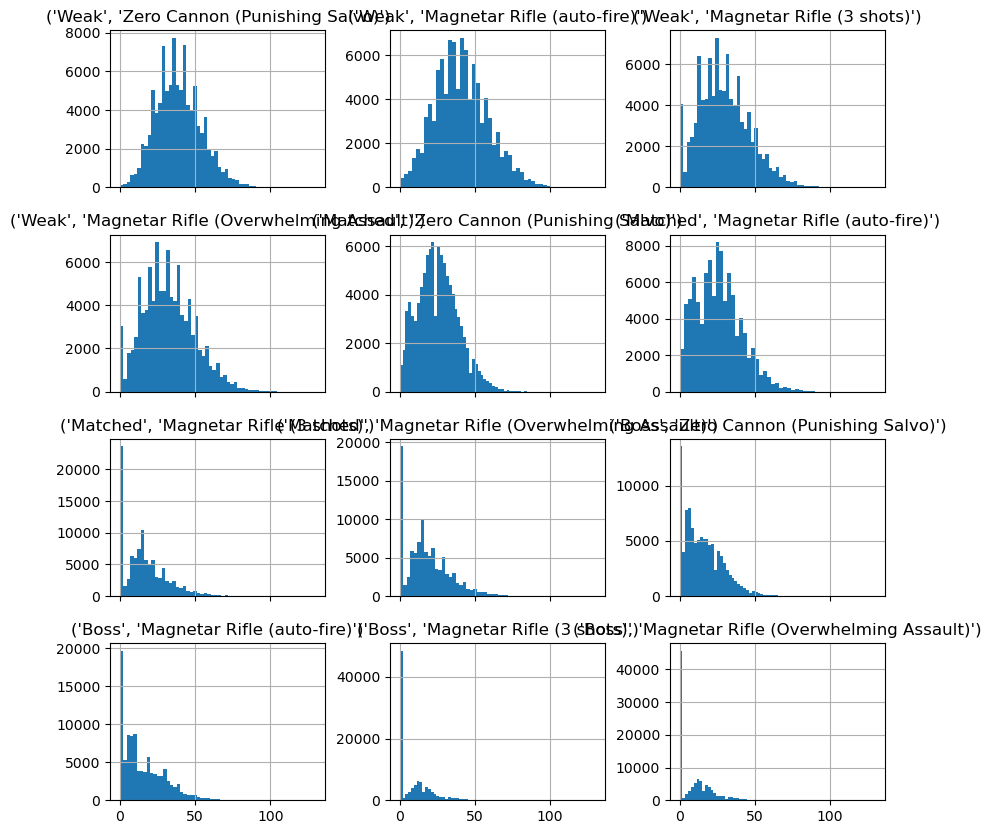

In [11]:
bins = full_round.total_damage.max().item() + 1
_ = (
    full_round.total_damage.stack(col=["challenge", "weapon"])
    .sum("action")
    .to_pandas()
    .hist(bins=bins, sharex=True, figsize=(10, 10))
)